# CICIoT2023 — Final Post-Balancing Data Understanding & Preprocessing Notebook

**Project:** Quantum-Inspired Federated Framework for Dynamic IoT Networks  
**Goal:** build a **clean, validated, documented, training-ready dataset bundle** for:
- centralized learning
- hierarchical learning
- federated learning
- later quantum-inspired experiments

---

## What this final notebook improves

This notebook merges and improves the previous V2/V3 workflows.

### Main fixes
- **`label_id_34` is removed completely** from the feature space because it contains many NaN values and should not be trusted as a training feature.
- A **new clean label encoding** is reconstructed from `label` only, using `LabelEncoder` fitted on the **train split only**.
- **Representative EDA** is done with **stratified sampling**, not by reading only the first rows of the CSV.
- **Near-constant features** are handled explicitly.
- **Highly correlated features** are filtered with a configurable threshold.
- **Heatmaps are generated both before and after preprocessing**, so you can visually compare correlation structure.
- **Feature selection is done before split** for global structural pruning.
- **Imputation / scaling / label encoding are fitted on train only** to avoid leakage.
- **Memory-safe export** is used to avoid crashes on very large splits.

### Important design choice
This notebook supports two experiment modes:

- `balanced_with_synthetic`
- `base_balanced_only`

This is important because your synthetic plausibility analysis suggests that some generated classes may be statistically distorted, so a clean baseline comparison is necessary.

In [1]:
from pathlib import Path
import json
import warnings
import pickle
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

## 1. Configuration

In [2]:
# ============================================================
# PATHS
# ============================================================
ORIGINAL_CLEAN_DATASET = Path(r"E:\dataset\processed\merged_full\dataset_34classes_clean.csv")
BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv")
SYNTHETIC_ONLY_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv")
BASE_BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv")
OLD_TRAINING_READY_DIR = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\training_ready")

# Optional portable override
PROJECT_ROOT = None
if PROJECT_ROOT is not None:
    ORIGINAL_CLEAN_DATASET = PROJECT_ROOT / "processed/merged_full/dataset_34classes_clean.csv"
    BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/dataset_34classes_balanced_v3.csv"
    SYNTHETIC_ONLY_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/synthetic_only_v3.csv"
    BASE_BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/base_balanced_without_synthetic_v3.csv"
    OLD_TRAINING_READY_DIR = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/training_ready"

# ============================================================
# DATA SOURCE MODE
# ============================================================
# "balanced_with_synthetic" -> current balanced dataset containing synthetic rows
# "base_balanced_only"      -> balanced base without synthetic rows
DATA_SOURCE_MODE = "base_balanced_only"

if DATA_SOURCE_MODE == "balanced_with_synthetic":
    INPUT_DATASET = BALANCED_DATASET
elif DATA_SOURCE_MODE == "base_balanced_only":
    INPUT_DATASET = BASE_BALANCED_DATASET
else:
    raise ValueError(f"Unknown DATA_SOURCE_MODE: {DATA_SOURCE_MODE}")

LABEL_COL = "label"
LEGACY_LABEL_ID_COL = "label_id_34"   # this one will be dropped entirely if present
NEW_LABEL_ID_NAME = "label_id"

# ============================================================
# OUTPUTS
# ============================================================
OUTPUT_DIR = INPUT_DATASET.parent / f"post_balancing_preprocessing_FINAL_{DATA_SOURCE_MODE}"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"
REPORTS_DIR = OUTPUT_DIR / "reports"
FIGURES_DIR = OUTPUT_DIR / "figures"
EXPORTS_DIR = OUTPUT_DIR / "exports"

for p in [OUTPUT_DIR, ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR, EXPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ============================================================
# EDA / SAMPLING
# ============================================================
EDA_ROWS_PER_CLASS = 5000
CORR_ROWS = 50000
PLOT_MAX_FEATURES = 10
PLAUSIBILITY_ROWS_PER_CLASS = 3000

# ============================================================
# SPLIT
# ============================================================
TEST_RATIO = 0.20
USE_VALIDATION = True
VAL_RATIO_FROM_TRAIN = 0.125   # gives approx 70/10/20 overall

# ============================================================
# CLEANING / FEATURE SELECTION
# ============================================================
DROP_DUPLICATES_TRAIN_ONLY = True
REMOVE_CONSTANT_FEATURES = True
REMOVE_NEAR_CONSTANT_FEATURES = True
NEAR_CONSTANT_THRESHOLD = 0.999
REMOVE_HIGH_CORR_FEATURES = True
HIGH_CORR_THRESHOLD = 0.90

# Correlation pruning rule:
# drop feature_b from each strong-correlation pair
CORR_FILTER_STRATEGY = "drop_feature_b"

# ============================================================
# TRANSFORMATION
# ============================================================
MISSING_NUMERIC_STRATEGY = "median"
SCALER_NAME = "robust"        # "robust" or "standard"
APPLY_LOG1P_TO_HEAVY_SKEW = False
SKEW_THRESHOLD_FOR_LOG1P = 5.0
CAST_FLOAT32 = True

# ============================================================
# EXPORT
# ============================================================
# To stay memory-safe on 10.2M rows:
# - NPZ export is enabled by default
# - chunked CSV export is available
EXPORT_NPZ = True
EXPORT_CHUNKED_CSV = True
CSV_CHUNK_SIZE = 200_000

print("DATA_SOURCE_MODE:", DATA_SOURCE_MODE)
print("INPUT_DATASET   :", INPUT_DATASET)
print("OUTPUT_DIR      :", OUTPUT_DIR)

DATA_SOURCE_MODE: base_balanced_only
INPUT_DATASET   : E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv
OUTPUT_DIR      : E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_FINAL_base_balanced_only


## 2. File inventory

In [3]:
file_inventory = pd.DataFrame([
    {"name": "original_clean_dataset", "path": str(ORIGINAL_CLEAN_DATASET), "exists": ORIGINAL_CLEAN_DATASET.exists()},
    {"name": "balanced_dataset", "path": str(BALANCED_DATASET), "exists": BALANCED_DATASET.exists()},
    {"name": "synthetic_only_dataset", "path": str(SYNTHETIC_ONLY_DATASET), "exists": SYNTHETIC_ONLY_DATASET.exists()},
    {"name": "base_balanced_dataset", "path": str(BASE_BALANCED_DATASET), "exists": BASE_BALANCED_DATASET.exists()},
    {"name": "old_training_ready_dir", "path": str(OLD_TRAINING_READY_DIR), "exists": OLD_TRAINING_READY_DIR.exists()},
])
file_inventory

,name,path,exists
0,original_clean_dataset,E:\dataset\processed\merged_full\dataset_34cla...,True
1,balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
2,synthetic_only_dataset,E:\dataset\processed_merged_full\minority_bala...,True
3,base_balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
4,old_training_ready_dir,E:\dataset\processed_merged_full\minority_bala...,True


## 3. Utility functions

In [4]:
def read_csv_safely(path: Path, nrows: Optional[int] = None, usecols=None) -> pd.DataFrame:
    assert path.exists(), f"File not found: {path}"
    return pd.read_csv(path, nrows=nrows, usecols=usecols)

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def detect_feature_columns(df: pd.DataFrame, label_col: str, legacy_label_id_col: str) -> Tuple[List[str], List[str], List[str]]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = [c for c in [legacy_label_id_col] if c in numeric_cols]
    feature_cols = [c for c in numeric_cols if c not in exclude]
    object_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    return numeric_cols, feature_cols, object_cols

def stratified_sample_per_class(df: pd.DataFrame, label_col: str, n_per_class: int, seed: int = 42) -> pd.DataFrame:
    parts = []
    for label, g in df.groupby(label_col, sort=False):
        parts.append(g.sample(n=min(len(g), n_per_class), random_state=seed))
    return pd.concat(parts, ignore_index=True)

def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        row = {
            "column": col,
            "dtype": str(s.dtype),
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "is_numeric": bool(pd.api.types.is_numeric_dtype(s)),
        }
        if pd.api.types.is_numeric_dtype(s):
            vc = s.value_counts(dropna=False, normalize=True)
            row.update({
                "min": float(s.min()) if len(s) else np.nan,
                "q01": float(s.quantile(0.01)) if len(s) else np.nan,
                "median": float(s.median()) if len(s) else np.nan,
                "mean": float(s.mean()) if len(s) else np.nan,
                "q99": float(s.quantile(0.99)) if len(s) else np.nan,
                "max": float(s.max()) if len(s) else np.nan,
                "std": float(s.std(ddof=0)) if len(s) else np.nan,
                "skew": float(s.skew()) if len(s) else np.nan,
                "zero_ratio": float((s == 0).mean()) if len(s) else np.nan,
                "top_value_ratio": float(vc.iloc[0]) if len(vc) else np.nan,
            })
        else:
            vc = s.value_counts(dropna=False, normalize=True)
            row.update({
                "min": None, "q01": None, "median": None, "mean": None,
                "q99": None, "max": None, "std": None, "skew": None,
                "zero_ratio": None, "top_value_ratio": float(vc.iloc[0]) if len(vc) else np.nan,
            })
        rows.append(row)
    summary = pd.DataFrame(rows)
    summary["is_constant"] = summary["n_unique"] <= 1
    summary["is_near_constant"] = summary["top_value_ratio"].fillna(0) >= NEAR_CONSTANT_THRESHOLD
    return summary

def iqr_outlier_ratio(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((s < low) | (s > high)).mean())

def build_feature_quality_report(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    rows = []
    for col in feature_cols:
        s = pd.to_numeric(df[col], errors="coerce")
        vc = s.value_counts(dropna=False, normalize=True)
        top_ratio = float(vc.iloc[0]) if len(vc) else np.nan
        rows.append({
            "feature": col,
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "zero_ratio": float((s == 0).mean()),
            "std": float(s.std(ddof=0)),
            "skew": float(s.skew()),
            "iqr_outlier_ratio": iqr_outlier_ratio(s),
            "is_constant": bool(s.nunique(dropna=False) <= 1),
            "top_value_ratio": top_ratio,
            "is_near_constant": bool((top_ratio if pd.notna(top_ratio) else 0.0) >= NEAR_CONSTANT_THRESHOLD),
        })
    return pd.DataFrame(rows).sort_values(
        ["is_constant", "is_near_constant", "missing_ratio", "iqr_outlier_ratio"],
        ascending=[False, False, False, False]
    )

def correlation_drop_candidates(df: pd.DataFrame, feature_cols: List[str], threshold: float = 0.90) -> pd.DataFrame:
    corr = df[feature_cols].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        strong = upper[col][upper[col] > threshold]
        for idx, val in strong.items():
            pairs.append({"feature_a": idx, "feature_b": col, "abs_spearman": float(val)})
    if len(pairs) == 0:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_spearman"])
    return pd.DataFrame(pairs).sort_values("abs_spearman", ascending=False)

def choose_corr_drop_list(corr_pairs_df: pd.DataFrame) -> List[str]:
    if corr_pairs_df.empty:
        return []
    to_drop = []
    for _, row in corr_pairs_df.iterrows():
        if CORR_FILTER_STRATEGY == "drop_feature_b":
            to_drop.append(row["feature_b"])
        else:
            to_drop.append(row["feature_b"])
    return sorted(set(to_drop))

def fit_scaler(name: str):
    if name.lower() == "robust":
        return RobustScaler()
    if name.lower() == "standard":
        return StandardScaler()
    raise ValueError(f"Unsupported scaler: {name}")

def optional_log1p_transform(train_df, val_df, test_df, feature_cols, skew_threshold=5.0):
    skew_vals = train_df[feature_cols].skew().abs()
    candidates = skew_vals[skew_vals > skew_threshold].index.tolist()
    safe_candidates = [c for c in candidates if train_df[c].min() >= 0]
    for d in [train_df, val_df, test_df]:
        if d is None:
            continue
        for c in safe_candidates:
            d[c] = np.log1p(d[c])
    return train_df, val_df, test_df, safe_candidates

def replace_inf_with_nan(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    out[cols] = out[cols].replace([np.inf, -np.inf], np.nan)
    return out

def export_split_chunked_csv(X_df: pd.DataFrame, y_label: pd.Series, y_id: pd.Series,
                             out_path: Path, chunk_size: int = 200_000):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    header_written = False
    n = len(X_df)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = X_df.iloc[start:end].copy()
        chunk[LABEL_COL] = y_label.iloc[start:end].values
        chunk[NEW_LABEL_ID_NAME] = y_id.iloc[start:end].values
        chunk.to_csv(out_path, mode="w" if not header_written else "a",
                     header=not header_written, index=False)
        header_written = True

def make_corr_heatmap(df: pd.DataFrame, feature_cols: List[str], title: str, path: Path,
                      sample_rows: int = 50000):
    if len(feature_cols) == 0:
        return
    sample = df[feature_cols].sample(n=min(len(df), sample_rows), random_state=SEED)
    corr = sample.corr(method="spearman")
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return corr

## 4. Load full dataset and remove legacy `label_id_34` from the working copy

In [5]:
full_input_df = read_csv_safely(INPUT_DATASET)
print("Full input dataset shape:", full_input_df.shape)

legacy_label_missing = None
if LEGACY_LABEL_ID_COL in full_input_df.columns:
    legacy_label_missing = int(full_input_df[LEGACY_LABEL_ID_COL].isna().sum())
    print(f"Legacy column `{LEGACY_LABEL_ID_COL}` found. Missing values:", legacy_label_missing)
else:
    print(f"Legacy column `{LEGACY_LABEL_ID_COL}` not found.")

# Keep original for reporting, but remove legacy label-id from the modeling frame
model_base_df = full_input_df.drop(columns=[LEGACY_LABEL_ID_COL], errors="ignore").copy()

print("Model base dataset shape after dropping legacy label-id column:", model_base_df.shape)
model_base_df.head()

Full input dataset shape: (6234645, 34)
Legacy column `label_id_34` found. Missing values: 0
Model base dataset shape after dropping legacy label-id column: (6234645, 33)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label
0,0.20,1.0,65.91,23952.396,0.0,0.00,0.01,0.00,0.01,0.0,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000042,100.0,0.00000,DDOS-ICMP_FLOOD
1,0.28,1.0,63.79,42499.790,0.0,0.01,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6002.0,60.0,62.0,60.02,0.20000,0.000024,100.0,0.04000,DDOS-ICMP_FLOOD
2,0.00,1.0,64.00,20538.164,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.00,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000049,100.0,0.00000,DDOS-ICMP_FLOOD
3,0.64,1.0,67.48,72716.780,0.0,0.00,0.00,0.01,0.02,0.0,2.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.98,0.0,6108.0,60.0,162.0,61.08,10.21158,0.000014,100.0,104.27637,DDOS-ICMP_FLOOD
4,0.32,1.0,63.96,47100.550,0.0,0.00,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6006.0,60.0,66.0,60.06,0.60000,0.000021,100.0,0.36000,DDOS-ICMP_FLOOD


### Why this is important
`label_id_34` contained many NaN values in your earlier runs and should not be used as a trusted training feature.

So in this final notebook:
- it is **dropped completely**
- a new clean `label_id` is reconstructed later from `label`

## 5. Build representative EDA sample

In [6]:
eda_df = stratified_sample_per_class(model_base_df, LABEL_COL, n_per_class=EDA_ROWS_PER_CLASS, seed=SEED)
print("Representative EDA shape:", eda_df.shape)
print("Number of classes in EDA sample:", eda_df[LABEL_COL].nunique())
eda_df.head()

Representative EDA shape: (160137, 33)
Number of classes in EDA sample: 34


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label
0,0.00,1.0,64.00,9595.096,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,1.00,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000104,100.0,0.0000,DDOS-ICMP_FLOOD
1,0.00,1.0,65.27,5127.135,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.01,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000195,100.0,0.0000,DDOS-ICMP_FLOOD
2,0.00,1.0,63.36,3008.805,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.01,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000333,100.0,0.0000,DDOS-ICMP_FLOOD
3,0.00,1.0,63.36,4734.191,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.01,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000211,100.0,0.0000,DDOS-ICMP_FLOOD
4,0.48,1.0,64.00,7614.931,0.0,0.0,0.0,0.01,0.01,0.0,1.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0,0.01,0.02,0.0,0.00,0.97,0.0,6377.0,60.0,379.0,63.77,32.10175,0.000132,100.0,1030.5223,DDOS-ICMP_FLOOD


In [7]:
numeric_cols, feature_cols, object_cols = detect_feature_columns(eda_df, LABEL_COL, LEGACY_LABEL_ID_COL)
print("Numeric columns :", len(numeric_cols))
print("Feature columns :", len(feature_cols))
print("Object columns  :", len(object_cols))
print("Feature preview :", feature_cols[:10])

Numeric columns : 32
Feature columns : 32
Object columns  : 1
Feature preview : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number']


## 6. Dataset volume and class distribution

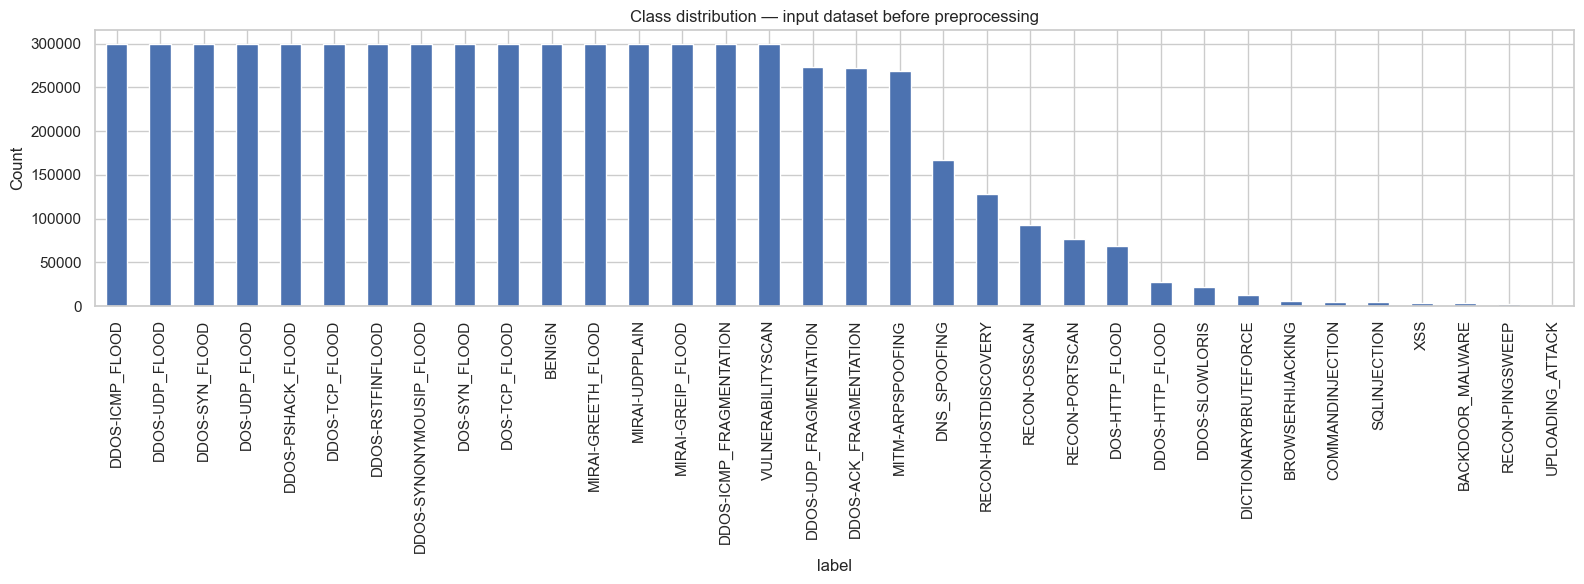

,label,count
0,DDOS-ICMP_FLOOD,300000
1,DDOS-UDP_FLOOD,300000
2,DDOS-SYN_FLOOD,300000
3,DOS-UDP_FLOOD,300000
4,DDOS-PSHACK_FLOOD,300000
5,DDOS-TCP_FLOOD,300000
6,DDOS-RSTFINFLOOD,300000
7,DDOS-SYNONYMOUSIP_FLOOD,300000
8,DOS-SYN_FLOOD,300000
9,DOS-TCP_FLOOD,300000


In [8]:
class_dist_full = model_base_df[LABEL_COL].value_counts().sort_values(ascending=False)
class_dist_eda = eda_df[LABEL_COL].value_counts().sort_values(ascending=False)

class_dist_full_df = class_dist_full.rename_axis("label").reset_index(name="count")
class_dist_full_df.to_csv(REPORTS_DIR / "class_distribution_full_before_preprocessing.csv", index=False)

plt.figure(figsize=(16, 6))
class_dist_full.plot(kind="bar")
plt.title("Class distribution — input dataset before preprocessing")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution_before_preprocessing.png", dpi=160, bbox_inches="tight")
plt.show()

class_dist_full_df.head(10)

## 7. Structural profiling and data quality audit

In [9]:
summary_df = summarize_dataframe(eda_df)
summary_df.to_csv(REPORTS_DIR / "column_summary_eda.csv", index=False)
summary_df.head(20)

,column,dtype,missing,missing_ratio,n_unique,is_numeric,min,q01,median,mean,q99,max,std,skew,zero_ratio,top_value_ratio,is_constant,is_near_constant
0,Header_Length,float64,0,0.0,1224,True,0.000000,0.000000,20.0000,17.987266,38.5200,60.0,10.539927,-0.119467,0.060867,0.125986,False,False
1,Protocol Type,float64,0,0.0,5,True,0.000000,1.000000,6.0000,10.425355,47.0000,47.0,10.524200,2.547294,0.005402,0.667310,False,False
2,Time_To_Live,float64,0,0.0,6085,True,0.000000,47.100000,64.4900,79.113640,218.9992,255.0,32.161815,2.575595,0.000337,0.292425,False,False
3,Rate,float64,0,0.0,115789,True,0.000021,17.449054,2094.7432,11512.536947,111610.0100,1997287.6,36222.051758,14.300799,0.000000,0.000312,False,False
4,fin_flag_number,float64,0,0.0,130,True,0.000000,0.000000,0.0000,0.045529,1.0000,1.0,0.176168,4.870003,0.815895,0.815895,False,False
5,syn_flag_number,float64,0,0.0,148,True,0.000000,0.000000,0.0000,0.143283,1.0000,1.0,0.304630,2.170194,0.635219,0.635219,False,False
6,rst_flag_number,float64,0,0.0,130,True,0.000000,0.000000,0.0000,0.065873,1.0000,1.0,0.211011,3.625861,0.830870,0.830870,False,False
7,psh_flag_number,float64,0,0.0,168,True,0.000000,0.000000,0.0000,0.124520,1.0000,1.0,0.214600,2.356471,0.529884,0.529884,False,False
8,ack_flag_number,float64,0,0.0,200,True,0.000000,0.000000,0.2600,0.378934,1.0000,1.0,0.394834,0.400391,0.323461,0.323461,False,False
9,ece_flag_number,float64,0,0.0,16,True,0.000000,0.000000,0.0000,0.000217,0.0000,0.7,0.006207,46.619657,0.996971,0.996971,False,False


In [10]:
inf_counts = pd.Series({
    col: np.isinf(pd.to_numeric(eda_df[col], errors="coerce")).sum()
    for col in feature_cols
}).sort_values(ascending=False)

missing_counts = eda_df.isna().sum().sort_values(ascending=False)
duplicate_count = int(eda_df.duplicated().sum())

print("Duplicate rows in EDA sample:", duplicate_count)
print("Top missing counts:")
display(missing_counts.head(20))
print("Top inf counts:")
display(inf_counts.head(20))

Duplicate rows in EDA sample: 0
Top missing counts:


Header_Length    0
IRC              0
Variance         0
Number           0
IAT              0
Std              0
AVG              0
Max              0
Min              0
Tot sum          0
IGMP             0
ICMP             0
ARP              0
DHCP             0
UDP              0
TCP              0
SSH              0
Protocol Type    0
SMTP             0
Telnet           0
dtype: int64

Top inf counts:


Header_Length    0
Protocol Type    0
Number           0
IAT              0
Std              0
AVG              0
Max              0
Min              0
Tot sum          0
IGMP             0
ICMP             0
ARP              0
DHCP             0
UDP              0
TCP              0
IRC              0
SSH              0
SMTP             0
Telnet           0
DNS              0
dtype: int64

In [11]:
feature_quality_df = build_feature_quality_report(eda_df, feature_cols)
feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_eda.csv", index=False)
feature_quality_df.head(20)

,feature,missing,missing_ratio,n_unique,zero_ratio,std,skew,iqr_outlier_ratio,is_constant,top_value_ratio,is_near_constant
14,Telnet,0,0.0,5,0.999038,0.001823,74.307998,0.000000,False,0.999038,True
24,Tot sum,0,0.0,28667,0.000000,29364.632271,1.657555,0.214148,False,0.167375,False
31,Variance,0,0.0,76803,0.252490,702335.804552,35.135003,0.212150,False,0.252490,False
10,ack_count,0,0.0,101,0.323461,27.553759,2.143034,0.157571,False,0.323461,False
5,syn_flag_number,0,0.0,148,0.635219,0.304630,2.170194,0.154461,False,0.635219,False
2,Time_To_Live,0,0.0,6085,0.000337,32.161815,2.575595,0.144170,False,0.292425,False
29,IAT,0,0.0,116674,0.000006,116.649342,399.797816,0.141922,False,0.000200,False
25,Min,0,0.0,468,0.000000,218.583115,5.318968,0.130844,False,0.683733,False
12,HTTPS,0,0.0,161,0.517326,0.327146,1.506892,0.123488,False,0.517326,False
19,UDP,0,0.0,179,0.456465,0.329478,1.461904,0.122333,False,0.456465,False


In [12]:
constant_candidates = feature_quality_df.loc[feature_quality_df["is_constant"], "feature"].tolist()
near_constant_candidates = feature_quality_df.loc[feature_quality_df["is_near_constant"], "feature"].tolist()

print("Constant features:", constant_candidates)
print("Near-constant features:", near_constant_candidates)

Constant features: []
Near-constant features: ['Telnet']


## 8. Feature distributions and outliers

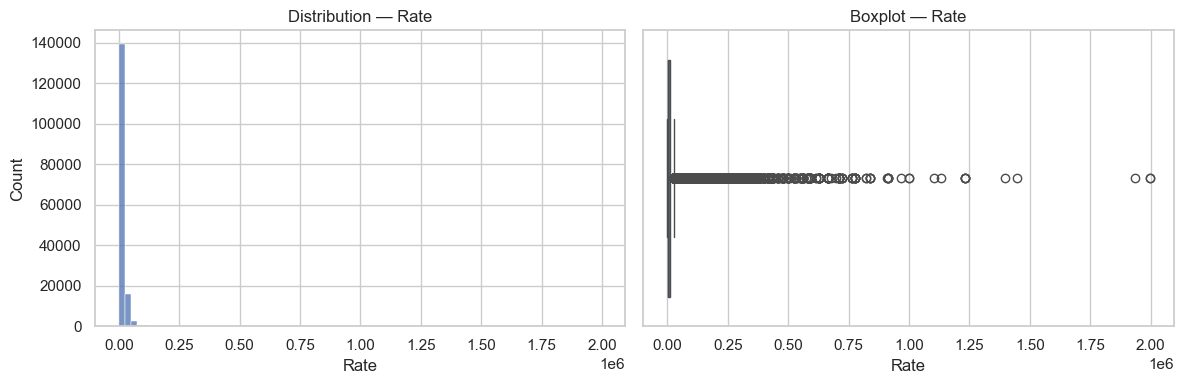

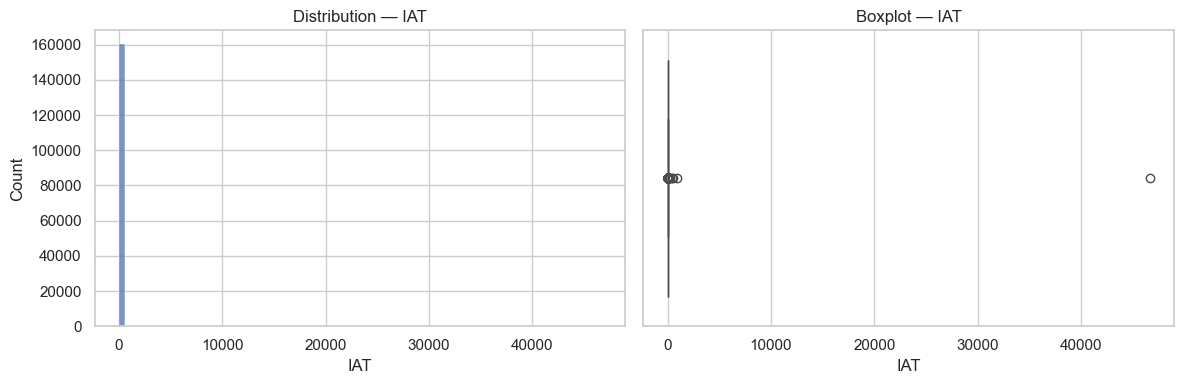

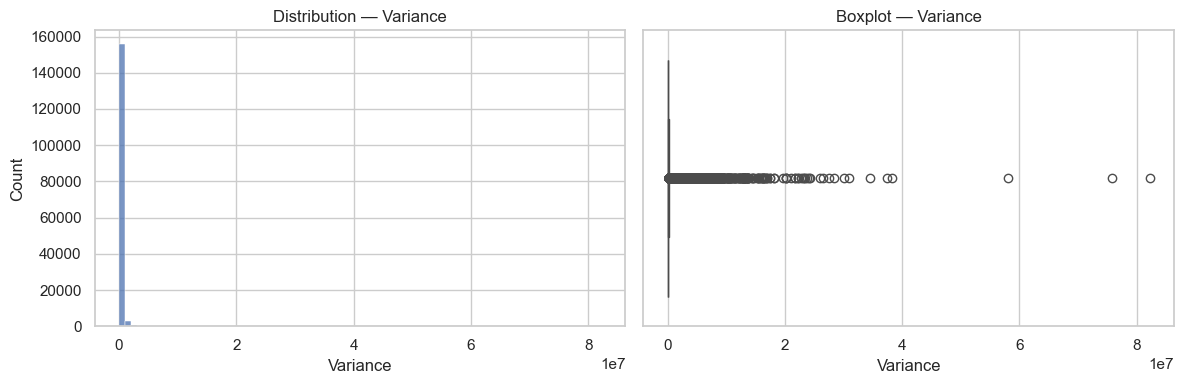

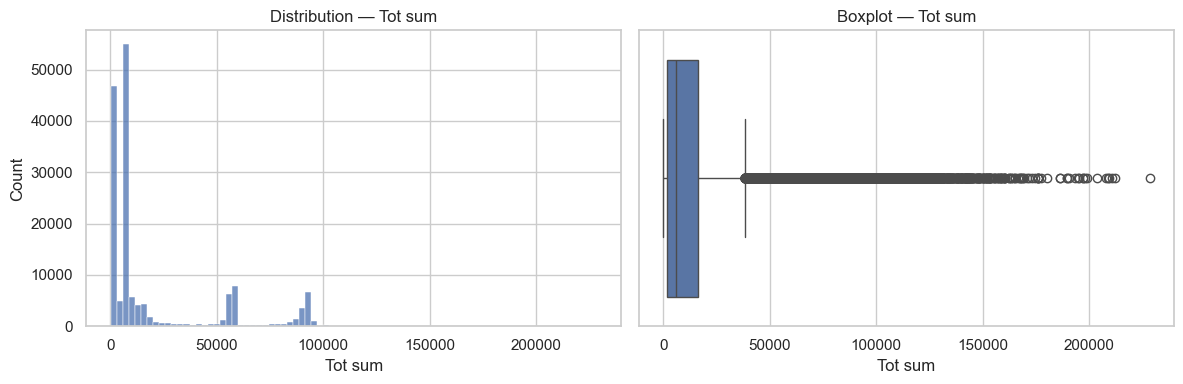

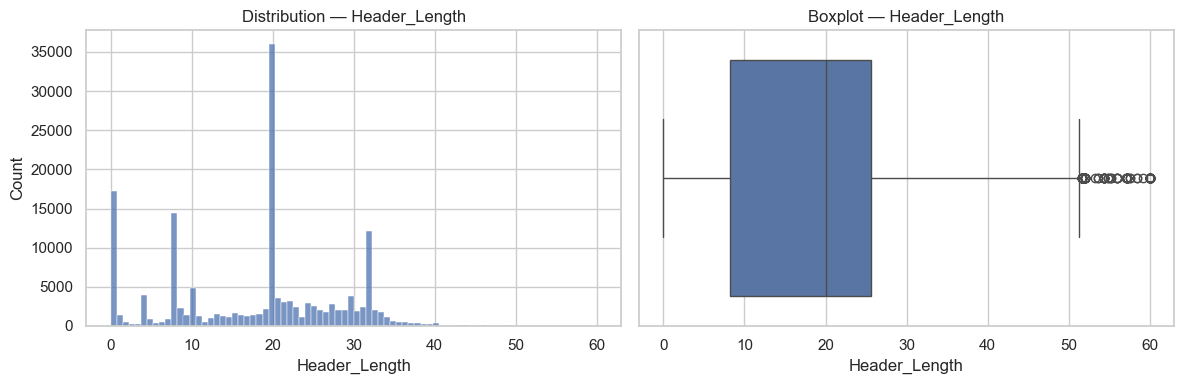

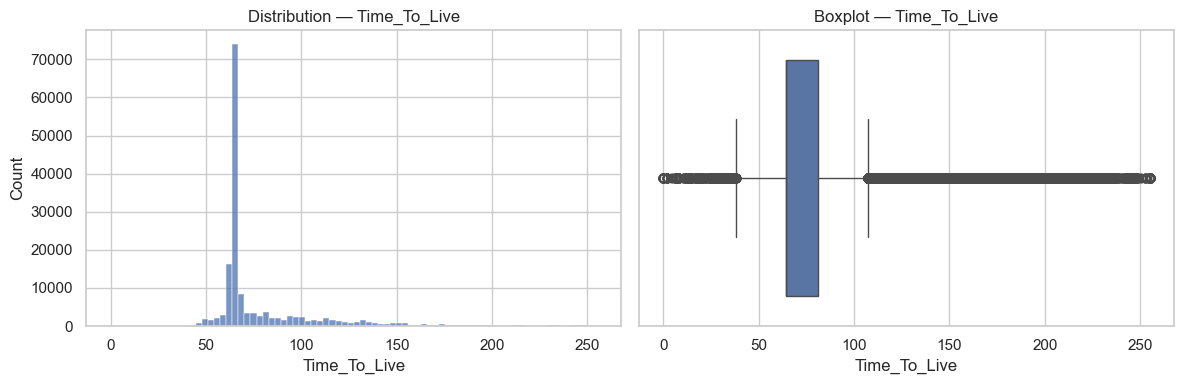

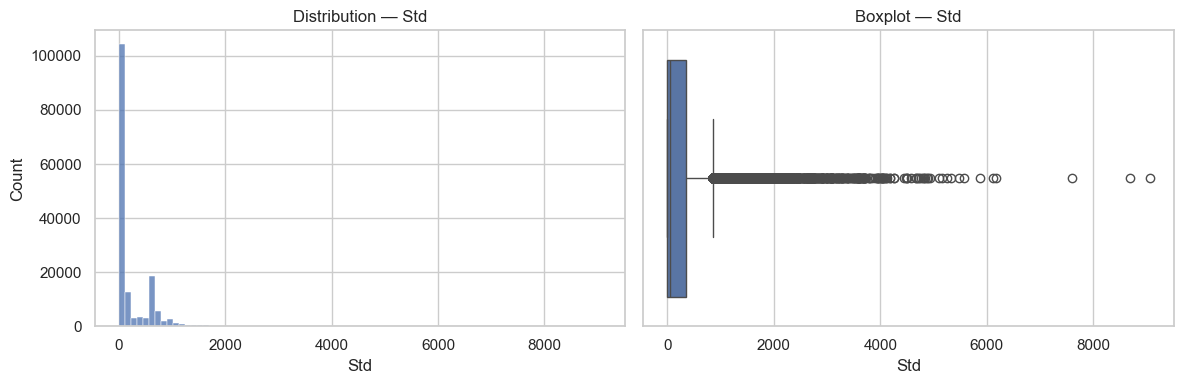

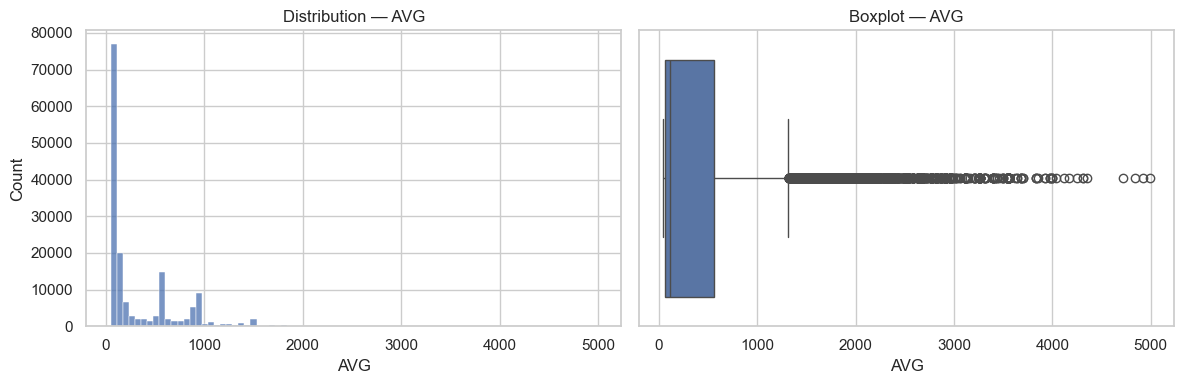

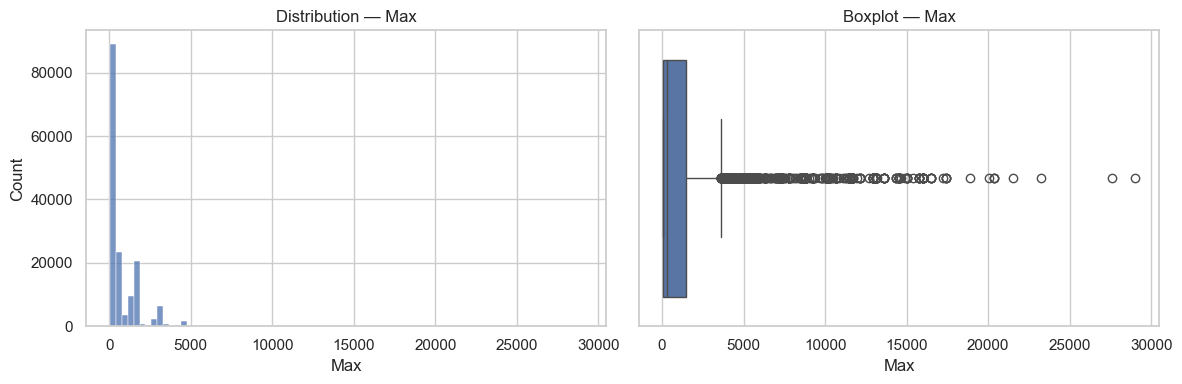

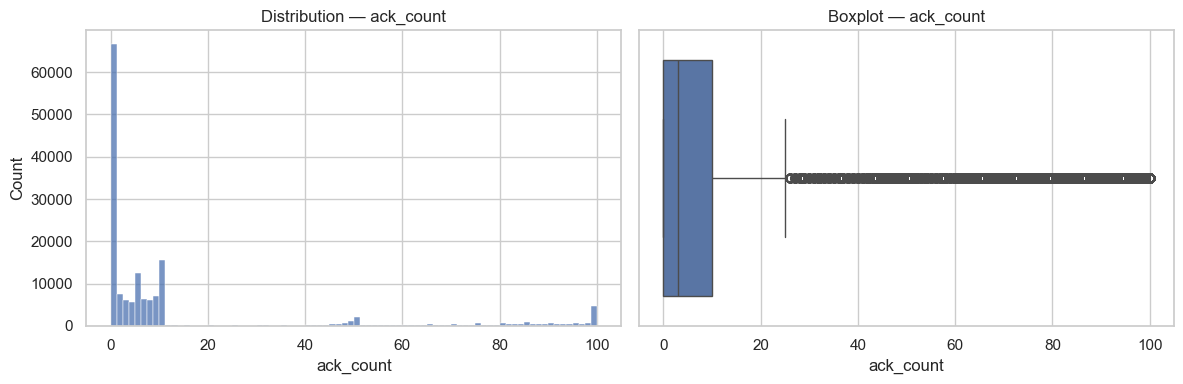

In [13]:
plot_cols = [c for c in ["Rate", "IAT", "Variance", "Tot sum", "Header_Length", "Time_To_Live", "Std", "AVG", "Max", "ack_count"] if c in feature_cols][:PLOT_MAX_FEATURES]

for col in plot_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(eda_df[col], bins=80, ax=axes[0], kde=False)
    axes[0].set_title(f"Distribution — {col}")
    sns.boxplot(x=eda_df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot — {col}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"dist_box_{col}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 9. Correlation heatmap BEFORE preprocessing

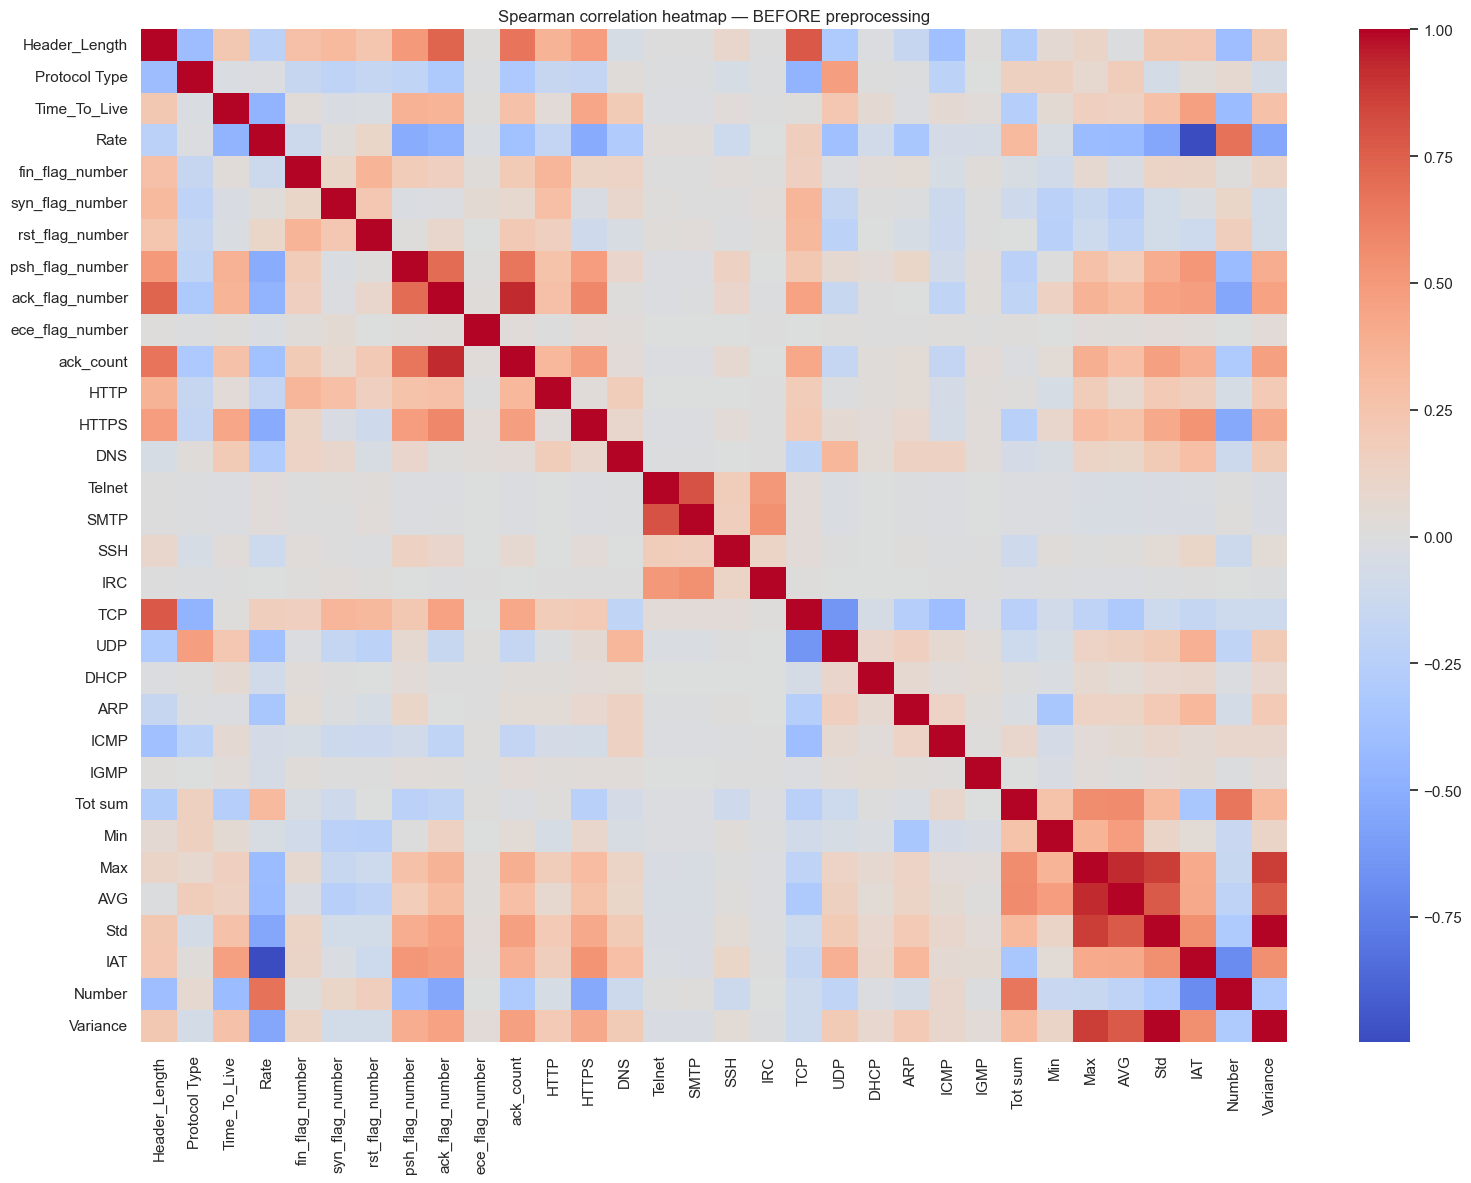

,feature_a,feature_b,abs_spearman
3,Std,Variance,1.000000
2,Rate,IAT,0.995760
0,ack_flag_number,ack_count,0.929416
1,Max,AVG,0.925726


In [14]:
corr_before = make_corr_heatmap(
    eda_df,
    feature_cols,
    title="Spearman correlation heatmap — BEFORE preprocessing",
    path=FIGURES_DIR / "correlation_heatmap_before_preprocessing.png",
    sample_rows=CORR_ROWS
)

high_corr_pairs_before = correlation_drop_candidates(
    eda_df.sample(n=min(len(eda_df), CORR_ROWS), random_state=SEED),
    feature_cols,
    threshold=HIGH_CORR_THRESHOLD
)
high_corr_pairs_before.to_csv(REPORTS_DIR / "high_correlation_pairs_before_preprocessing.csv", index=False)
high_corr_pairs_before.head(30)

This heatmap is the **before** view.

Later, after feature selection and scaling, we will generate a second heatmap to show the **after** view.

## 10. Synthetic plausibility analysis

In [15]:
plausibility_summary_df = pd.DataFrame(columns=["label", "abs_mean_diff", "real_std", "synth_std"])

if SYNTHETIC_ONLY_DATASET.exists() and BASE_BALANCED_DATASET.exists():
    base_full = read_csv_safely(BASE_BALANCED_DATASET).drop(columns=[LEGACY_LABEL_ID_COL], errors="ignore")
    synth_full = read_csv_safely(SYNTHETIC_ONLY_DATASET).drop(columns=[LEGACY_LABEL_ID_COL], errors="ignore")

    base_df = stratified_sample_per_class(base_full, LABEL_COL, n_per_class=PLAUSIBILITY_ROWS_PER_CLASS, seed=SEED)
    synth_df = stratified_sample_per_class(synth_full, LABEL_COL, n_per_class=PLAUSIBILITY_ROWS_PER_CLASS, seed=SEED)

    rows = []
    common_labels = sorted(set(base_df[LABEL_COL].unique()).intersection(set(synth_df[LABEL_COL].unique())))
    print("Common labels between base and synthetic:", common_labels)

    current_features = [c for c in feature_cols if c in base_df.columns and c in synth_df.columns]
    for label in common_labels:
        real_part = base_df[base_df[LABEL_COL] == label]
        synth_part = synth_df[synth_df[LABEL_COL] == label]
        if len(real_part) == 0 or len(synth_part) == 0:
            continue
        for col in current_features:
            rows.append({
                "label": label,
                "feature": col,
                "real_mean": float(real_part[col].mean()),
                "synth_mean": float(synth_part[col].mean()),
                "abs_mean_diff": float(abs(real_part[col].mean() - synth_part[col].mean())),
                "real_std": float(real_part[col].std(ddof=0)),
                "synth_std": float(synth_part[col].std(ddof=0)),
            })

    if len(rows) > 0:
        plausibility_df = pd.DataFrame(rows)
        plausibility_df.to_csv(REPORTS_DIR / "synthetic_plausibility_report.csv", index=False)
        plausibility_summary_df = (
            plausibility_df.groupby("label")[["abs_mean_diff", "real_std", "synth_std"]]
            .mean()
            .reset_index()
            .sort_values("abs_mean_diff")
        )
        plausibility_summary_df.to_csv(REPORTS_DIR / "synthetic_plausibility_summary.csv", index=False)

plausibility_summary_df.head(20)

Common labels between base and synthetic: ['BACKDOOR_MALWARE', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'UPLOADING_ATTACK', 'XSS']


,label,abs_mean_diff,real_std,synth_std
9,DOS-HTTP_FLOOD,35.018822,14914.087462,12056.562664
8,DNS_SPOOFING,63.081454,7830.443242,6271.002843
3,DDOS-ACK_FRAGMENTATION,98.903567,3916.703683,1230.581608
15,SQLINJECTION,170.500031,14932.714323,6792.352568
6,DDOS-UDP_FRAGMENTATION,187.164997,4162.704266,1003.342961
2,COMMANDINJECTION,257.533029,29863.372532,13955.266287
5,DDOS-SLOWLORIS,283.494797,21696.284479,15488.471835
13,RECON-PINGSWEEP,319.178721,25908.716936,16533.586936
4,DDOS-HTTP_FLOOD,337.763135,8014.125383,5436.185180
16,UPLOADING_ATTACK,346.190231,27477.593127,15017.414843


### Interpretation
If `abs_mean_diff` is high and `synth_std` is much smaller than `real_std`, synthetic data may be too smooth or distorted.

That does **not** automatically invalidate synthetic data, but it means you should compare:
- `balanced_with_synthetic`
- `base_balanced_only`

## 11. Split first, then fit train-only artifacts

In [16]:
full_df = model_base_df.copy()

train_df, test_df = train_test_split(
    full_df,
    test_size=TEST_RATIO,
    stratify=full_df[LABEL_COL],
    random_state=SEED,
)

if USE_VALIDATION:
    train_df, val_df = train_test_split(
        train_df,
        test_size=VAL_RATIO_FROM_TRAIN,
        stratify=train_df[LABEL_COL],
        random_state=SEED,
    )
else:
    val_df = None

print("Train shape before cleaning:", train_df.shape)
print("Val shape before cleaning  :", None if val_df is None else val_df.shape)
print("Test shape before cleaning :", test_df.shape)

Train shape before cleaning: (4364251, 33)
Val shape before cleaning  : (623465, 33)
Test shape before cleaning : (1246929, 33)


## 12. Train-only cleaning preparation
We now:
- replace `Inf` with `NaN`
- optionally remove duplicate rows **from train only**
- do the feature audit on **train only**

In [17]:
numeric_cols_train, feature_cols_train, object_cols_train = detect_feature_columns(train_df, LABEL_COL, LEGACY_LABEL_ID_COL)

train_df = replace_inf_with_nan(train_df, feature_cols_train)
test_df = replace_inf_with_nan(test_df, feature_cols_train)
if val_df is not None:
    val_df = replace_inf_with_nan(val_df, feature_cols_train)

train_dup_before = int(train_df.duplicated().sum())
if DROP_DUPLICATES_TRAIN_ONLY and train_dup_before > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)

print("Train duplicates removed:", train_dup_before)
print("Train shape after train-only dedup:", train_df.shape)

Train duplicates removed: 0
Train shape after train-only dedup: (4364251, 33)


## 13. Feature selection decisions

In [18]:
train_feature_quality_df = build_feature_quality_report(train_df, feature_cols_train)
train_feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_train.csv", index=False)

constant_features_train = train_feature_quality_df.loc[train_feature_quality_df["is_constant"], "feature"].tolist()
near_constant_features_train = train_feature_quality_df.loc[train_feature_quality_df["is_near_constant"], "feature"].tolist()

features_to_drop = []
if REMOVE_CONSTANT_FEATURES:
    features_to_drop.extend(constant_features_train)
if REMOVE_NEAR_CONSTANT_FEATURES:
    features_to_drop.extend(near_constant_features_train)

features_to_drop = sorted(set(features_to_drop))
selected_feature_cols = [c for c in feature_cols_train if c not in features_to_drop]

print("Constant features (train):", constant_features_train)
print("Near-constant features (train):", near_constant_features_train)
print("Dropped after constant / near-constant audit:", features_to_drop)
print("Selected feature count after step 1:", len(selected_feature_cols))

Constant features (train): []
Near-constant features (train): []
Dropped after constant / near-constant audit: []
Selected feature count after step 1: 32


In [19]:
corr_pairs_train = pd.DataFrame(columns=["feature_a", "feature_b", "abs_spearman"])

if REMOVE_HIGH_CORR_FEATURES:
    corr_pairs_train = correlation_drop_candidates(
        train_df[selected_feature_cols].sample(min(len(train_df), 100_000), random_state=SEED),
        selected_feature_cols,
        threshold=HIGH_CORR_THRESHOLD,
    )
    corr_pairs_train.to_csv(REPORTS_DIR / "high_correlation_pairs_train.csv", index=False)

    to_drop_corr = choose_corr_drop_list(corr_pairs_train)
    selected_feature_cols = [c for c in selected_feature_cols if c not in to_drop_corr]

    print("Correlation threshold:", HIGH_CORR_THRESHOLD)
    print("Dropped due to high correlation:", sorted(to_drop_corr))
    print("Selected feature count after step 2:", len(selected_feature_cols))
else:
    print("High-correlation filtering disabled.")

Correlation threshold: 0.9
Dropped due to high correlation: ['AVG', 'IAT', 'Variance', 'ack_count']
Selected feature count after step 2: 28


In [20]:
pd.DataFrame({
    "feature": selected_feature_cols,
    "order": range(len(selected_feature_cols))
}).to_csv(ARTIFACTS_DIR / "selected_features_pre_split.csv", index=False)

feature_selection_summary = {
    "initial_feature_count": int(len(feature_cols_train)),
    "constant_features_train": constant_features_train,
    "near_constant_features_train": near_constant_features_train,
    "dropped_after_constant_near_constant": features_to_drop,
    "correlation_threshold": HIGH_CORR_THRESHOLD,
    "high_corr_pairs_found": int(len(corr_pairs_train)),
    "dropped_due_to_correlation": choose_corr_drop_list(corr_pairs_train),
    "final_selected_feature_count": int(len(selected_feature_cols)),
}
save_json(feature_selection_summary, REPORTS_DIR / "feature_selection_summary.json")
feature_selection_summary

{'initial_feature_count': 32,
 'constant_features_train': [],
 'near_constant_features_train': [],
 'dropped_after_constant_near_constant': [],
 'correlation_threshold': 0.9,
 'high_corr_pairs_found': 4,
 'dropped_due_to_correlation': ['AVG', 'IAT', 'Variance', 'ack_count'],
 'final_selected_feature_count': 28}

## 14. Prepare X / y splits

In [21]:
X_train = train_df[selected_feature_cols].copy()
y_train = train_df[LABEL_COL].copy()

X_test = test_df[selected_feature_cols].copy()
y_test = test_df[LABEL_COL].copy()

if val_df is not None:
    X_val = val_df[selected_feature_cols].copy()
    y_val = val_df[LABEL_COL].copy()
else:
    X_val, y_val = None, None

print("X_train:", X_train.shape)
print("X_val  :", None if X_val is None else X_val.shape)
print("X_test :", X_test.shape)

X_train: (4364251, 28)
X_val  : (623465, 28)
X_test : (1246929, 28)


## 15. Imputation, optional log transform, scaling, clean label reconstruction

In [22]:
imputer = SimpleImputer(strategy=MISSING_NUMERIC_STRATEGY)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=selected_feature_cols)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=selected_feature_cols)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=selected_feature_cols) if X_val is not None else None

log1p_applied_features = []
if APPLY_LOG1P_TO_HEAVY_SKEW:
    X_train_imp, X_val_imp, X_test_imp, log1p_applied_features = optional_log1p_transform(
        X_train_imp, X_val_imp, X_test_imp, selected_feature_cols, skew_threshold=SKEW_THRESHOLD_FOR_LOG1P
    )

scaler = fit_scaler(SCALER_NAME)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=selected_feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=selected_feature_cols)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), columns=selected_feature_cols) if X_val_imp is not None else None

if CAST_FLOAT32:
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    if X_val_scaled is not None:
        X_val_scaled = X_val_scaled.astype(np.float32)

# Rebuild clean label_id from label only
label_encoder = LabelEncoder()
y_train_enc = pd.Series(label_encoder.fit_transform(y_train), name=NEW_LABEL_ID_NAME)
y_test_enc = pd.Series(label_encoder.transform(y_test), name=NEW_LABEL_ID_NAME)
y_val_enc = pd.Series(label_encoder.transform(y_val), name=NEW_LABEL_ID_NAME) if y_val is not None else None

classes = np.unique(y_train_enc)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_enc)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

print("Selected feature count:", len(selected_feature_cols))
print("Number of classes:", len(label_encoder.classes_))

Selected feature count: 28
Number of classes: 34


## 16. Correlation heatmap AFTER preprocessing

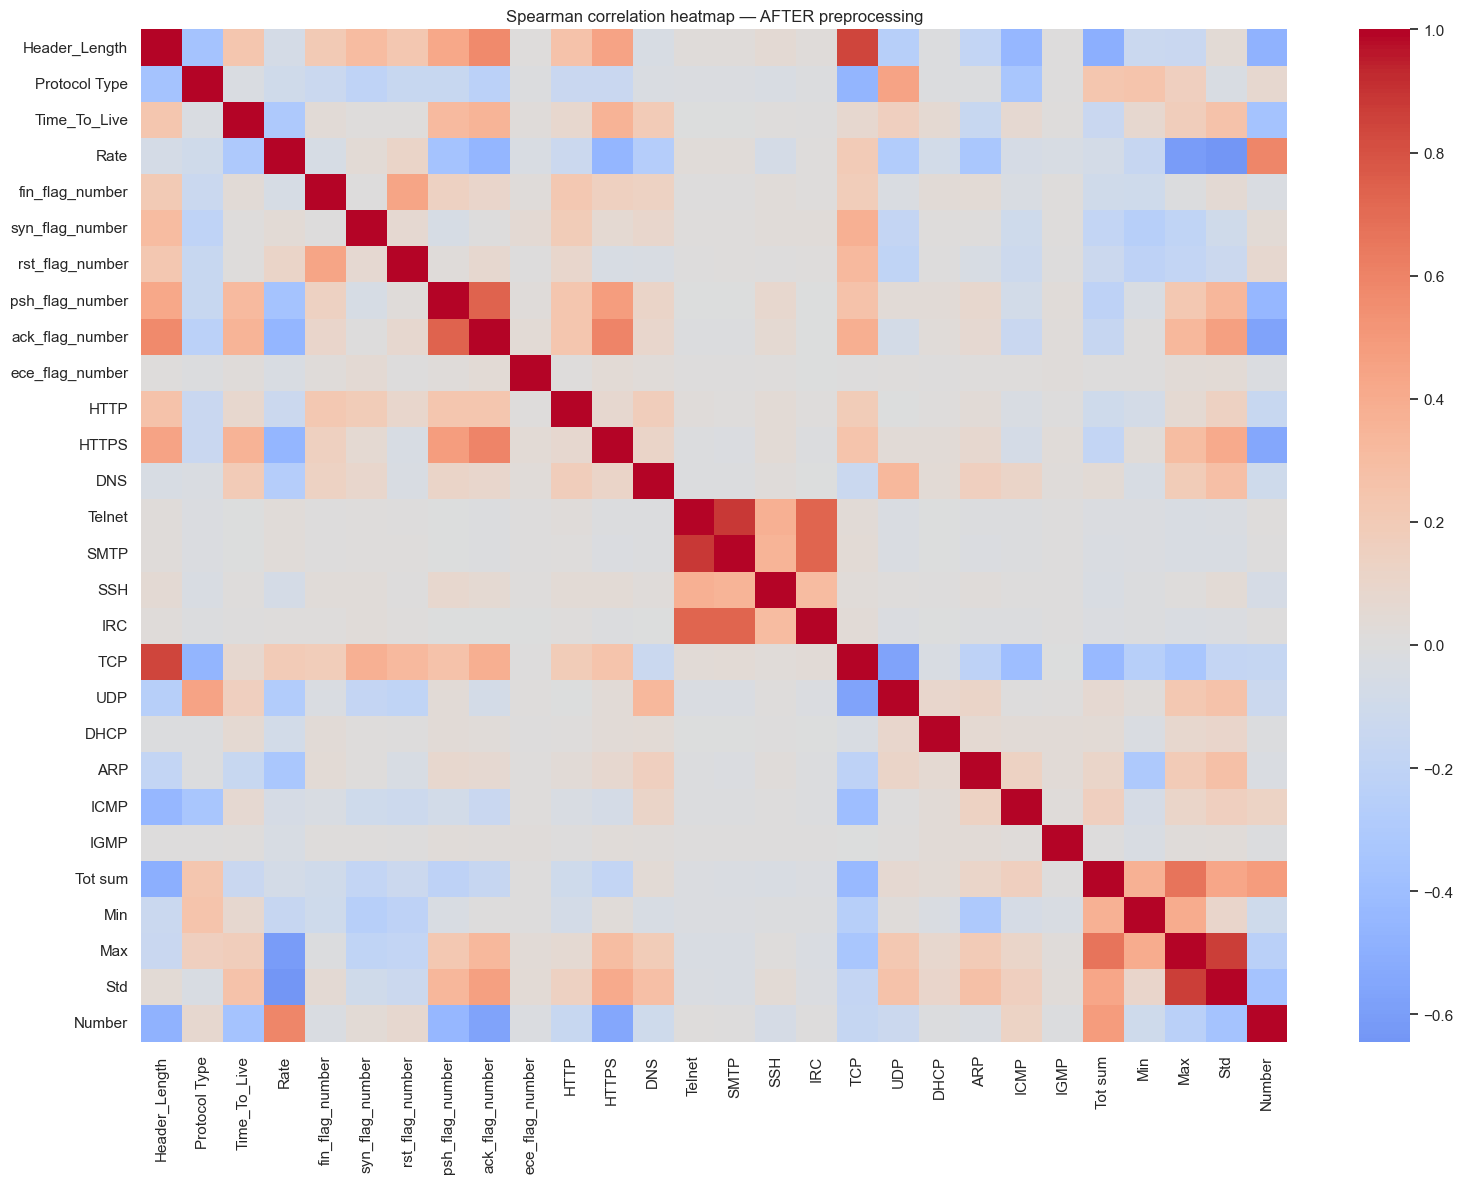

In [23]:
corr_after = make_corr_heatmap(
    X_train_scaled,
    selected_feature_cols,
    title="Spearman correlation heatmap — AFTER preprocessing",
    path=FIGURES_DIR / "correlation_heatmap_after_preprocessing.png",
    sample_rows=CORR_ROWS
)

Now you have:
- **before preprocessing heatmap**
- **after preprocessing heatmap**

This lets you visually compare correlation structure before and after the pruning/scaling pipeline.

## 17. Memory-safe export

In [24]:
# Save arrays first (safe and efficient)
if EXPORT_NPZ:
    np.savez_compressed(EXPORTS_DIR / "train_arrays.npz", X=X_train_scaled.values, y=y_train_enc.values)
    np.savez_compressed(EXPORTS_DIR / "test_arrays.npz", X=X_test_scaled.values, y=y_test_enc.values)
    if X_val_scaled is not None:
        np.savez_compressed(EXPORTS_DIR / "val_arrays.npz", X=X_val_scaled.values, y=y_val_enc.values)

# Optional chunked CSV export to avoid MemoryError
if EXPORT_CHUNKED_CSV:
    export_split_chunked_csv(X_train_scaled, y_train.reset_index(drop=True), y_train_enc.reset_index(drop=True),
                             EXPORTS_DIR / "train_ready.csv", chunk_size=CSV_CHUNK_SIZE)
    export_split_chunked_csv(X_test_scaled, y_test.reset_index(drop=True), y_test_enc.reset_index(drop=True),
                             EXPORTS_DIR / "test_ready.csv", chunk_size=CSV_CHUNK_SIZE)
    if X_val_scaled is not None:
        export_split_chunked_csv(X_val_scaled, y_val.reset_index(drop=True), y_val_enc.reset_index(drop=True),
                                 EXPORTS_DIR / "val_ready.csv", chunk_size=CSV_CHUNK_SIZE)

# Save preprocessing artifacts
with open(ARTIFACTS_DIR / "imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
with open(ARTIFACTS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACTS_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(ARTIFACTS_DIR / "class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

pd.DataFrame({
    "feature": selected_feature_cols,
    "order": range(len(selected_feature_cols))
}).to_csv(ARTIFACTS_DIR / "selected_features.csv", index=False)

pd.DataFrame({
    "label": label_encoder.classes_,
    NEW_LABEL_ID_NAME: range(len(label_encoder.classes_))
}).to_csv(ARTIFACTS_DIR / "label_mapping.csv", index=False)

pd.DataFrame({
    "class_id": list(class_weight_dict.keys()),
    "weight": list(class_weight_dict.values())
}).to_csv(ARTIFACTS_DIR / "class_weights.csv", index=False)

print("Exports saved to  :", EXPORTS_DIR)
print("Artifacts saved to:", ARTIFACTS_DIR)

Exports saved to  : E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_FINAL_base_balanced_only\exports
Artifacts saved to: E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_FINAL_base_balanced_only\artifacts


## 18. Before / after comparison

In [25]:
# Compare class retention after export logic (counts should remain the same)
class_before = full_df[LABEL_COL].value_counts().sort_index()

combined_after_labels = pd.concat([
    y_train.reset_index(drop=True),
    y_test.reset_index(drop=True),
    y_val.reset_index(drop=True) if y_val is not None else pd.Series([], dtype=object)
], ignore_index=True)

class_after = combined_after_labels.value_counts().sort_index()

compare_dist_df = pd.DataFrame({
    "count_before": class_before,
    "count_after": class_after,
})
compare_dist_df["retention_ratio"] = compare_dist_df["count_after"] / compare_dist_df["count_before"]
compare_dist_df = compare_dist_df.reset_index().rename(columns={"index": "label"})
compare_dist_df.to_csv(REPORTS_DIR / "class_distribution_before_after_preprocessing.csv", index=False)
compare_dist_df.head(20)

,label,count_before,count_after,retention_ratio
0,BACKDOOR_MALWARE,3075,3075,1.0
1,BENIGN,300000,300000,1.0
2,BROWSERHIJACKING,5560,5560,1.0
3,COMMANDINJECTION,5150,5150,1.0
4,DDOS-ACK_FRAGMENTATION,271537,271537,1.0
5,DDOS-HTTP_FLOOD,27597,27597,1.0
6,DDOS-ICMP_FLOOD,300000,300000,1.0
7,DDOS-ICMP_FRAGMENTATION,300000,300000,1.0
8,DDOS-PSHACK_FLOOD,300000,300000,1.0
9,DDOS-RSTFINFLOOD,300000,300000,1.0


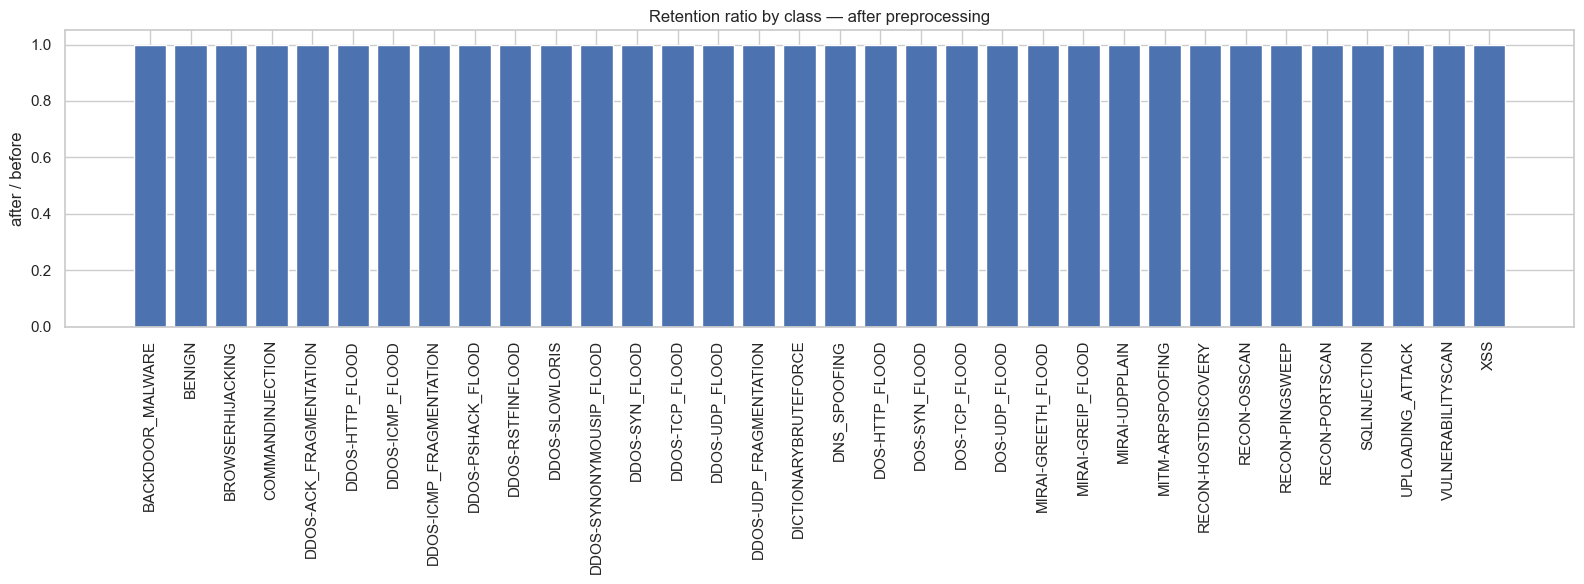

In [26]:
plt.figure(figsize=(16, 6))
plt.bar(compare_dist_df["label"], compare_dist_df["retention_ratio"])
plt.title("Retention ratio by class — after preprocessing")
plt.ylabel("after / before")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_retention_ratio_after_preprocessing.png", dpi=160, bbox_inches="tight")
plt.show()

In [27]:
comparison_metrics = pd.DataFrame([
    {"stage": "input_full", "rows": len(full_df), "features": len(feature_cols_train)},
    {"stage": "train_final", "rows": len(X_train_scaled), "features": len(selected_feature_cols)},
    {"stage": "val_final", "rows": 0 if X_val_scaled is None else len(X_val_scaled), "features": len(selected_feature_cols)},
    {"stage": "test_final", "rows": len(X_test_scaled), "features": len(selected_feature_cols)},
])
comparison_metrics.to_csv(REPORTS_DIR / "dataset_size_before_after_preprocessing.csv", index=False)
comparison_metrics

,stage,rows,features
0,input_full,6234645,32
1,train_final,4364251,28
2,val_final,623465,28
3,test_final,1246929,28


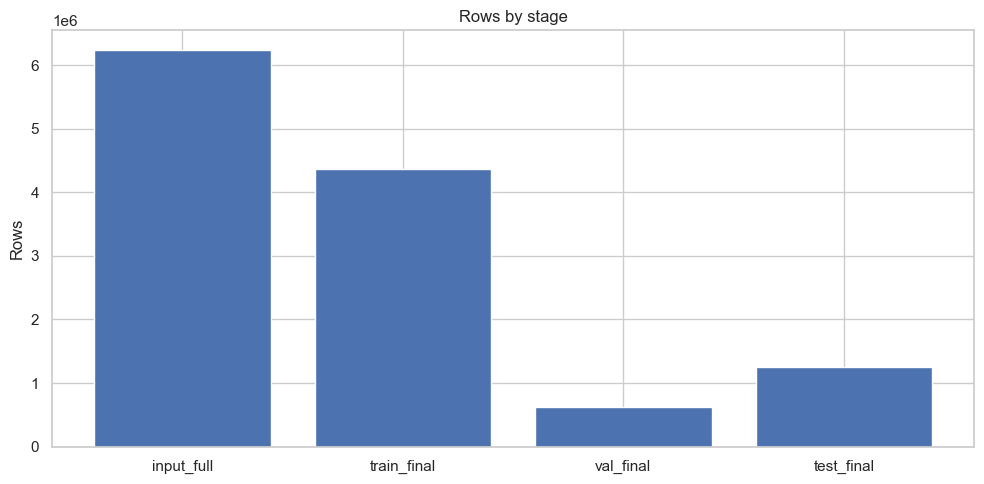

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison_metrics["stage"], comparison_metrics["rows"])
ax.set_title("Rows by stage")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rows_by_stage.png", dpi=160, bbox_inches="tight")
plt.show()

## 19. Sanity checks

In [29]:
sanity = {
    "legacy_label_id_column_present_in_input": bool(LEGACY_LABEL_ID_COL in full_input_df.columns),
    "legacy_label_id_missing_count": None if legacy_label_missing is None else int(legacy_label_missing),
    "train_has_nan": bool(np.isnan(X_train_scaled.values).any()),
    "test_has_nan": bool(np.isnan(X_test_scaled.values).any()),
    "val_has_nan": bool(np.isnan(X_val_scaled.values).any()) if X_val_scaled is not None else False,
    "train_has_inf": bool(np.isinf(X_train_scaled.values).any()),
    "test_has_inf": bool(np.isinf(X_test_scaled.values).any()),
    "val_has_inf": bool(np.isinf(X_val_scaled.values).any()) if X_val_scaled is not None else False,
    "n_selected_features": int(len(selected_feature_cols)),
    "n_classes": int(len(label_encoder.classes_)),
    "train_rows": int(len(X_train_scaled)),
    "val_rows": int(0 if X_val_scaled is None else len(X_val_scaled)),
    "test_rows": int(len(X_test_scaled)),
}
save_json(sanity, REPORTS_DIR / "sanity_checks.json")
sanity

{'legacy_label_id_column_present_in_input': True,
 'legacy_label_id_missing_count': 0,
 'train_has_nan': False,
 'test_has_nan': False,
 'val_has_nan': False,
 'train_has_inf': False,
 'test_has_inf': False,
 'val_has_inf': False,
 'n_selected_features': 28,
 'n_classes': 34,
 'train_rows': 4364251,
 'val_rows': 623465,
 'test_rows': 1246929}

## 20. Final preprocessing summary

In [30]:
pipeline_summary = {
    "data_source_mode": DATA_SOURCE_MODE,
    "input_dataset": str(INPUT_DATASET),
    "legacy_label_id_column_dropped": True,
    "legacy_label_id_missing_count": None if legacy_label_missing is None else int(legacy_label_missing),
    "initial_feature_count": int(len(feature_cols_train)),
    "selected_feature_count": int(len(selected_feature_cols)),
    "dropped_features": sorted(set(features_to_drop + choose_corr_drop_list(corr_pairs_train))),
    "scaler_name": SCALER_NAME,
    "missing_numeric_strategy": MISSING_NUMERIC_STRATEGY,
    "apply_log1p": APPLY_LOG1P_TO_HEAVY_SKEW,
    "log1p_features": log1p_applied_features,
    "test_ratio": TEST_RATIO,
    "use_validation": USE_VALIDATION,
    "seed": SEED,
    "train_shape": [int(len(X_train_scaled)), int(X_train_scaled.shape[1] + 2)],
    "val_shape": None if X_val_scaled is None else [int(len(X_val_scaled)), int(X_val_scaled.shape[1] + 2)],
    "test_shape": [int(len(X_test_scaled)), int(X_test_scaled.shape[1] + 2)],
}
save_json(pipeline_summary, REPORTS_DIR / "preprocessing_pipeline_summary.json")
pipeline_summary

{'data_source_mode': 'base_balanced_only',
 'input_dataset': 'E:\\dataset\\processed_merged_full\\minority_balancing_v3\\base_balanced_without_synthetic_v3.csv',
 'legacy_label_id_column_dropped': True,
 'legacy_label_id_missing_count': 0,
 'initial_feature_count': 32,
 'selected_feature_count': 28,
 'dropped_features': ['AVG', 'IAT', 'Variance', 'ack_count'],
 'scaler_name': 'robust',
 'missing_numeric_strategy': 'median',
 'apply_log1p': False,
 'log1p_features': [],
 'test_ratio': 0.2,
 'use_validation': True,
 'seed': 42,
 'train_shape': [4364251, 30],
 'val_shape': [623465, 30],
 'test_shape': [1246929, 30]}

## 21. Publish compact report

In [31]:
report_lines = []
report_lines.append("# Final Post-Balancing Preprocessing Report")
report_lines.append("")
report_lines.append(f"- Data source mode: `{DATA_SOURCE_MODE}`")
report_lines.append(f"- Input dataset: `{INPUT_DATASET}`")
report_lines.append(f"- Legacy `{LEGACY_LABEL_ID_COL}` dropped: `True`")
report_lines.append(f"- Legacy `{LEGACY_LABEL_ID_COL}` missing values: `{legacy_label_missing}`")
report_lines.append(f"- Initial features: `{len(feature_cols_train)}`")
report_lines.append(f"- Selected features: `{len(selected_feature_cols)}`")
report_lines.append(f"- Dropped features: `{sorted(set(features_to_drop + choose_corr_drop_list(corr_pairs_train)))}`")
report_lines.append(f"- Scaler: `{SCALER_NAME}`")
report_lines.append(f"- Missing strategy: `{MISSING_NUMERIC_STRATEGY}`")
report_lines.append(f"- Log1p applied: `{APPLY_LOG1P_TO_HEAVY_SKEW}`")
report_lines.append(f"- Train rows: `{len(X_train_scaled):,}`")
report_lines.append(f"- Val rows: `{0 if X_val_scaled is None else len(X_val_scaled):,}`")
report_lines.append(f"- Test rows: `{len(X_test_scaled):,}`")
report_lines.append("")
report_lines.append("## Main decisions")
report_lines.append("")
report_lines.append("- `label_id_34` is removed and rebuilt cleanly as a new train-based `label_id`.")
report_lines.append("- Representative EDA uses stratified class sampling.")
report_lines.append("- Heatmaps are generated before and after preprocessing.")
report_lines.append("- Constant / near-constant / high-correlation pruning is applied in a structured way.")
report_lines.append("- Imputer, scaler, and label encoder are fit on train only.")
report_lines.append("- Memory-safe exports are used to avoid crashes on very large datasets.")

report_path = REPORTS_DIR / "PREPROCESSING_REPORT_FINAL.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Saved report:", report_path)

Saved report: E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_FINAL_base_balanced_only\reports\PREPROCESSING_REPORT_FINAL.md


## 22. Recommended next steps

1. Run this notebook once with `DATA_SOURCE_MODE = "balanced_with_synthetic"`.
2. Run it again with `DATA_SOURCE_MODE = "base_balanced_only"`.
3. Compare:
   - `preprocessing_pipeline_summary.json`
   - `feature_selection_summary.json`
   - `synthetic_plausibility_summary.csv`
   - correlation heatmaps before / after
4. Use the exported artifacts for:
   - flat baseline
   - hierarchical baseline
   - later federated learning